In [1]:
import pandas as pd
from pathlib import Path

In [2]:
# --- par‑box ---------------------------------------------------------------
path_box   = Path("/home/loai/Documents/code/RSMLExtraction/Results/Measures/results_per_box.csv")
df_box_wid = pd.read_csv(path_box)
df_box_wid

,model,split,box,metric,time,Prediction,expertized,before_expertized
0,Segformer_bce_dice,Val,230629PN006,NumberOfPlants,1,5.000000,5.000000,5.000000
1,Segformer_bce_dice,Val,230629PN006,NumberOfOrgans,1,5.000000,5.000000,5.000000
2,Segformer_bce_dice,Val,230629PN006,TotalRootLength,1,937.896972,938.425333,938.425333
3,Segformer_bce_dice,Val,230629PN006,NumberOfLateralRoots,1,0.000000,0.000000,0.000000
4,Segformer_bce_dice,Val,230629PN006,NumberOfPlants,2,5.000000,5.000000,5.000000
...,...,...,...,...,...,...,...,...
6955,Unet_bce_dice,Test,230629PN024,NumberOfLateralRoots,28,93.000000,75.000000,70.000000
6956,Unet_bce_dice,Test,230629PN024,NumberOfPlants,29,5.000000,4.000000,5.000000
6957,Unet_bce_dice,Test,230629PN024,NumberOfOrgans,29,98.000000,79.000000,75.000000
6958,Unet_bce_dice,Test,230629PN024,TotalRootLength,29,11055.597227,9543.186016,9552.798533


In [3]:
df_long = df_box_wid.melt(
    id_vars=['model', 'split', 'box', 'metric', 'time'],
    value_vars=['Prediction', 'expertized', 'before_expertized'],
    var_name='Type',
    value_name='Value'
)
df_long

,model,split,box,metric,time,Type,Value
0,Segformer_bce_dice,Val,230629PN006,NumberOfPlants,1,Prediction,5.000000
1,Segformer_bce_dice,Val,230629PN006,NumberOfOrgans,1,Prediction,5.000000
2,Segformer_bce_dice,Val,230629PN006,TotalRootLength,1,Prediction,937.896972
3,Segformer_bce_dice,Val,230629PN006,NumberOfLateralRoots,1,Prediction,0.000000
4,Segformer_bce_dice,Val,230629PN006,NumberOfPlants,2,Prediction,5.000000
...,...,...,...,...,...,...,...
20875,Unet_bce_dice,Test,230629PN024,NumberOfLateralRoots,28,before_expertized,70.000000
20876,Unet_bce_dice,Test,230629PN024,NumberOfPlants,29,before_expertized,5.000000
20877,Unet_bce_dice,Test,230629PN024,NumberOfOrgans,29,before_expertized,75.000000
20878,Unet_bce_dice,Test,230629PN024,TotalRootLength,29,before_expertized,9552.798533


In [4]:
df_grouped = df_long.groupby(['model', 'split', 'box', 'metric', 'Type', 'time'])

# order by time
df_grouped = df_grouped.apply(lambda x: x.sort_values(by='time'))

# print the first few rows of the grouped DataFrame
df_grouped.head()

/tmp/ipykernel_53479/4189136754.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_grouped = df_grouped.apply(lambda x: x.sort_values(by='time'))


model  \
model         split box         metric               Type       time                       
Segformer_bce Test  230629PN008 NumberOfLateralRoots Prediction 1    3251  Segformer_bce   
                                                                2    3255  Segformer_bce   
                                                                3    3259  Segformer_bce   
                                                                4    3263  Segformer_bce   
                                                                5    3267  Segformer_bce   

                                                                          split  \
model         split box         metric               Type       time              
Segformer_bce Test  230629PN008 NumberOfLateralRoots Prediction 1    3251  Test   
                                                                2    3255  Test   
                                                                3    3259  Test   
                                                                4    3263  Test   
                                                                5    3267  Test   

                                                                                   box  \
model         split box         metric               Type       time                     
Segformer_bce Test  230629PN008 NumberOfLateralRoots Prediction 1    3251  230629PN008   
                                                                2    3255  230629PN008   
                                                                3    3259  230629PN008   
                                                                4    3263  230629PN008   
                                                                5    3267  230629PN008   

                                                                                         metric  \
model         split box         metric               Type       time                              
Segformer_bce Test  230629PN008 NumberOfLateralRoots Prediction 1    3251  NumberOfLateralRoots   
                                                                2    3255  NumberOfLateralRoots   
                                                                3    3259  NumberOfLateralRoots   
                                                                4    3263  NumberOfLateralRoots   
                                                                5    3267  NumberOfLateralRoots   

                                                                           time  \
model         split box         metric               Type       time              
Segformer_bce Test  230629PN008 NumberOfLateralRoots Prediction 1    3251     1   
                                                                2    3255     2   
                                                                3    3259     3   
                                                                4    3263     4   
                                                                5    3267     5   

                                                                                 Type  \
model         split box         metric               Type       time                    
Segformer_bce Test  230629PN008 NumberOfLateralRoots Prediction 1    3251  Prediction   
                                                                2    3255  Prediction   
                                                                3    3259  Prediction   
                                                                4    3263  Prediction   
                                                                5    3267  Prediction   

                                                                           Value  
model         split box         metric               Type       time              
Segformer_bce Test  230629PN008 NumberOfLateralRoots Prediction 1    3251    0.0  
                                                                2    3255   

## plots

In [5]:
# for the first model, split, box and metric. for the 3 types, plot on the same graph the evolution of the value over time

import seaborn as sns
import matplotlib.pyplot as plt

models  = df_grouped.index.get_level_values('model').unique()
splits  = df_grouped.index.get_level_values('split').unique()
boxes   = df_grouped.index.get_level_values('box').unique()
metrics = df_grouped.index.get_level_values('metric').unique()

print("Models disponibles :", models)
print("Splits disponibles :", splits)
print("Boxes disponibles  :", boxes)
print("Metrics disponibles:", metrics)

Models disponibles : Index(['Segformer_bce', 'Segformer_bce_dice', 'Unet_bce', 'Unet_bce_dice',
       'Unet_dice', 'Unet_dice_cldice'],
      dtype='object', name='model')
Splits disponibles : Index(['Test', 'Val'], dtype='object', name='split')
Boxes disponibles  : Index(['230629PN008', '230629PN010', '230629PN018', '230629PN024',
       '230629PN027', '230629PN006', '230629PN012', '230629PN014',
       '230629PN019', '230629PN031'],
      dtype='object', name='box')
Metrics disponibles: Index(['NumberOfLateralRoots', 'NumberOfOrgans', 'NumberOfPlants',
       'TotalRootLength'],
      dtype='object', name='metric')


In [6]:
print("Number of unique Models:", len(models))
print("Number of unique Splits:", len(splits))
print("Number of unique Boxes:", len(boxes))
print("Number of unique Metrics:", len(metrics))

Number of unique Models: 6
Number of unique Splits: 2
Number of unique Boxes: 10
Number of unique Metrics: 4


In [7]:
models_num  = 0
splits_num = 1
boxes_num   = 3
metrics_num = 3
boxes_num += splits_num * 5

selected_model  = models[models_num]
selected_split  = splits[splits_num]
selected_box    = boxes[boxes_num] 
selected_metric = metrics[metrics_num]  

print(f"Modèle sélectionné  : {selected_model}")
print(f"Split sélectionné  : {selected_split}")
print(f"Boîte sélectionnée  : {selected_box}")
print(f"Métrique sélectionnée: {selected_metric}")

Modèle sélectionné  : Segformer_bce
Split sélectionné  : Val
Boîte sélectionnée  : 230629PN019
Métrique sélectionnée: TotalRootLength


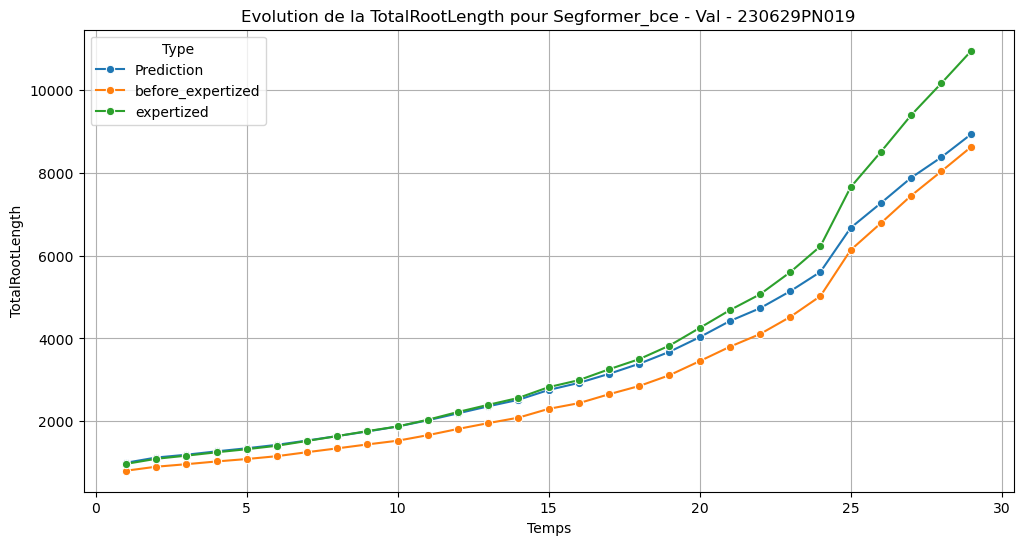

In [8]:
# plot
import matplotlib.pyplot as plt
import seaborn as sns

# Extraction
df_temp = df_grouped.xs(
    (selected_model, selected_split, selected_box, selected_metric),
    level=('model','split','box','metric')
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_temp,
    x='time',
    y='Value',
    hue='Type',
    marker='o'
)
plt.title(f"Evolution de la {selected_metric} pour {selected_model} - {selected_split} - {selected_box}")
plt.xlabel('Temps')
plt.ylabel(selected_metric)
plt.legend(title='Type')
plt.grid(True)
plt.show()

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

models  = df_grouped.index.get_level_values('model').unique()
splits  = df_grouped.index.get_level_values('split').unique()
boxes   = df_grouped.index.get_level_values('box').unique()
metrics = df_grouped.index.get_level_values('metric').unique()

def plot_evolution(model_idx, split_idx, box_idx, metric_idx):
    model  = models[model_idx]
    split  = splits[split_idx]

    box    = boxes[box_idx + split_idx * 5]
    metric = metrics[metric_idx]
    
    df_temp = df_grouped.xs(
        (model, split, box, metric),
        level=('model','split','box','metric')
    )
    
    plt.figure(figsize=(16, 8))
    sns.lineplot(
        data=df_temp,
        x='time', y='Value',
        hue='Type', marker='o'
    )
    plt.title(f"{metric} – {model} / {split} / {box}")
    plt.xlabel('Temps')
    plt.ylabel(metric)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

model_slider  = widgets.IntSlider(  min=0, max=len(models)-1,    step=1, value=0,
                                  description='Model idx')
split_slider  = widgets.IntSlider(  min=0, max=len(splits)-1,    step=1, value=0,
                                  description='Split idx')
box_slider    = widgets.IntSlider(  min=0, max=4,                step=1, value=0,
                                  description='Box idx')
metric_slider = widgets.IntSlider(  min=0, max=len(metrics)-1,   step=1, value=0,
                                  description='Metric idx')

ui = widgets.HBox([model_slider, split_slider, box_slider, metric_slider])
out = widgets.interactive_output(
    plot_evolution,
    {'model_idx': model_slider,
     'split_idx': split_slider,
     'box_idx': box_slider,
     'metric_idx': metric_slider}
)

display(ui, out)


Output()

In [14]:
from IPython.display import Markdown, display
import pandas as pd

# --- 1) Lecture et mise en forme longue (vous avez déjà df_long) ---
# df_box_wid = pd.read_csv(path_box)
# df_long   = df_box_wid.melt(
#     id_vars=['model','split','box','metric','time'],
#     value_vars=['Prediction','expertized','before_expertized'],
#     var_name='Type',
#     value_name='Value'
# )

# --- 2) Pivot pour avoir Prediction, expertized, before_expertized en colonnes ---
df_wide = (
    df_long
    .pivot_table(
        index=['model','split','box','metric','time'],
        columns='Type',
        values='Value'
    )
    .reset_index()
)

# --- 3) Calcul des écarts signés vs. avant/après expertisation ---
df_wide['err_before'] = df_wide['Prediction'] - df_wide['before_expertized']
df_wide['err_expert'] = df_wide['Prediction'] - df_wide['expertized']

# --- 4) Agrégation par modèle & métrique ---
summary = (
    df_wide
    .groupby(['model','metric'])
    .agg(
        biais_avant = ('err_before',  'mean'),
        MAE_avant   = ('err_before',  lambda x: x.abs().mean()),
        biais_apres = ('err_expert',  'mean'),
        MAE_apres   = ('err_expert',  lambda x: x.abs().mean()),
    )
    .round(3)
    .reset_index()
)

# --- 5) Affichage : un DataFrame par métrique, stylé en Jupyter ---
for metric, df_m in summary.groupby('metric'):
    df_m = (
        df_m[['model','biais_avant','MAE_avant','biais_apres','MAE_apres']]
        .rename(columns={
            'model'       : 'Model',
            'bias_before' : 'Biais with RST output',
            'MAE_before'  : 'MAE  with RST output',
            'bias_expert' : 'Biais with expertized',
            'MAE_expert'  : 'MAE with expertized',
        })
        .set_index('Model')
    )
    display(Markdown(f"## Measure : **{metric}**"))
    display(
        df_m.style
            .format("{:.3f}")
            .background_gradient(axis=1, cmap='coolwarm')
    )


## Measure : **NumberOfLateralRoots**

,biais_avant,MAE_avant,biais_apres,MAE_apres
Model,,,,
Segformer_bce,-4.386,4.841,-8.783,8.866
Segformer_bce_dice,-3.259,3.962,-7.655,7.910
Unet_bce,3.328,3.921,-1.069,5.172
Unet_bce_dice,3.686,3.790,-0.710,4.876
Unet_dice,-1.607,2.724,-6.003,6.348
Unet_dice_cldice,3.438,4.155,-0.959,5.214


## Measure : **NumberOfOrgans**

,biais_avant,MAE_avant,biais_apres,MAE_apres
Model,,,,
Segformer_bce,-3.986,5.028,-8.083,8.717
Segformer_bce_dice,-2.859,4.162,-6.955,7.810
Unet_bce,3.728,4.259,-0.369,5.334
Unet_bce_dice,4.086,4.169,-0.010,5.059
Unet_dice,-1.207,3.007,-5.303,6.255
Unet_dice_cldice,3.838,4.507,-0.259,5.500


## Measure : **NumberOfPlants**

,biais_avant,MAE_avant,biais_apres,MAE_apres
Model,,,,
Segformer_bce,0.400,0.400,0.700,0.700
Segformer_bce_dice,0.400,0.400,0.700,0.700
Unet_bce,0.400,0.400,0.700,0.700
Unet_bce_dice,0.400,0.400,0.700,0.700
Unet_dice,0.400,0.400,0.700,0.700
Unet_dice_cldice,0.400,0.400,0.700,0.700


## Measure : **TotalRootLength**

,biais_avant,MAE_avant,biais_apres,MAE_apres
Model,,,,
Segformer_bce,110.660,392.845,-40.967,512.897
Segformer_bce_dice,124.953,368.830,-26.674,477.675
Unet_bce,371.283,396.181,219.655,409.644
Unet_bce_dice,373.309,383.689,221.682,384.908
Unet_dice,149.267,352.564,-2.361,454.978
Unet_dice_cldice,351.475,391.377,199.847,397.901
